# Experiment-8

#### GAN

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [10]:
batch_size = 128
noise_dim = 2
lr = 0.0002
epochs = 2000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
def get_real_samples(batch_size):
    x = torch.randn(batch_size, 1)
    y = -x
    data = torch.cat([x, y], dim=1)
    return data.to(device)

In [12]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, z):
        return self.model(z)

In [13]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [14]:
G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_G = optim.Adam(G.parameters(), lr=lr)
optimizer_D = optim.Adam(D.parameters(), lr=lr)

In [15]:
for epoch in range(epochs):
    # Train Discriminator
    real_data = get_real_samples(batch_size)
    real_labels = torch.ones(batch_size, 1).to(device)

    noise = torch.randn(batch_size, noise_dim).to(device)
    fake_data = G(noise)
    fake_labels = torch.zeros(batch_size, 1).to(device)

    real_preds = D(real_data)
    fake_preds = D(fake_data.detach())

    loss_real = criterion(real_preds, real_labels)
    loss_fake = criterion(fake_preds, fake_labels)
    loss_D = loss_real + loss_fake

    optimizer_D.zero_grad()
    loss_D.backward()
    optimizer_D.step()

    # Train Generator
    noise = torch.randn(batch_size, noise_dim).to(device)
    fake_data = G(noise)
    fake_preds = D(fake_data)

    loss_G = criterion(fake_preds, real_labels)

    optimizer_G.zero_grad()
    loss_G.backward()
    optimizer_G.step()

    if epoch % 200 == 0:
        print(f"Epoch {epoch} | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

Epoch 0 | D Loss: 1.3734 | G Loss: 0.6921
Epoch 200 | D Loss: 1.2817 | G Loss: 0.7029
Epoch 400 | D Loss: 1.2318 | G Loss: 0.7822
Epoch 600 | D Loss: 1.2488 | G Loss: 0.7504
Epoch 800 | D Loss: 1.5321 | G Loss: 0.6202
Epoch 1000 | D Loss: 1.2762 | G Loss: 0.8931
Epoch 1200 | D Loss: 1.1266 | G Loss: 1.0271
Epoch 1400 | D Loss: 1.2124 | G Loss: 0.8341
Epoch 1600 | D Loss: 1.6845 | G Loss: 0.5959
Epoch 1800 | D Loss: 1.3747 | G Loss: 0.9233


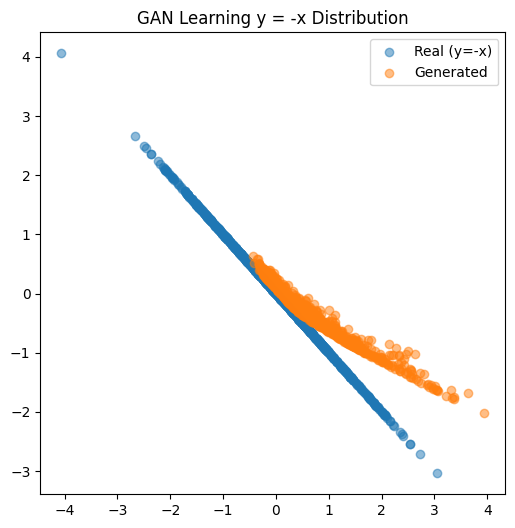

In [16]:
noise = torch.randn(1000, noise_dim).to(device)
generated = G(noise).detach().cpu()

real = get_real_samples(1000).cpu()

plt.figure(figsize=(6,6))
plt.scatter(real[:,0], real[:,1], label="Real (y=-x)", alpha=0.5)
plt.scatter(generated[:,0], generated[:,1], label="Generated", alpha=0.5)
plt.legend()
plt.title("GAN Learning y = -x Distribution")
plt.show()

#### Diffussion

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

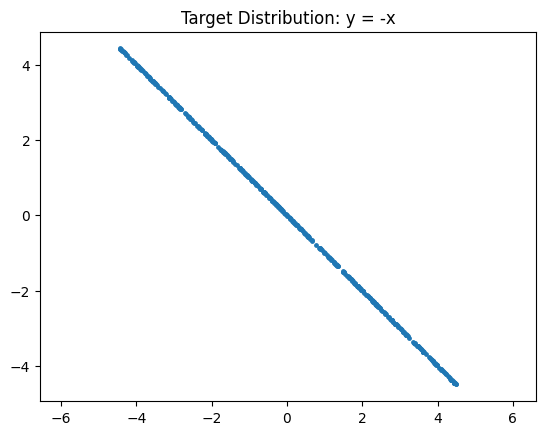

In [29]:
def sample_line_data(n_samples=512):
    x = torch.empty(n_samples, 1).uniform_(-4.5, 4.5)
    y = -x
    return torch.cat([x, y], dim=1)

plt.scatter(*sample_line_data(500).T, s=6)
plt.title("Target Distribution: y = -x")
plt.axis("equal")
plt.show()

In [30]:
steps = 120

betas = torch.linspace(2e-4, 0.015, steps)
alphas = 1.0 - betas
alpha_cum = torch.cumprod(alphas, dim=0)

In [31]:
def diffuse(x0, t_idx):
    noise = torch.randn_like(x0)

    a_bar = alpha_cum[t_idx].view(-1, 1)
    x_t = torch.sqrt(a_bar) * x0 + torch.sqrt(1 - a_bar) * noise

    return x_t, noise

In [33]:
class NoiseEstimator(nn.Module):
    def __init__(self, dim=2, hidden=128):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(dim + 16, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, dim)
        )

    def time_embed(self, t):
        half = 8
        freqs = torch.exp(torch.linspace(0, 3, half))
        t = t.float().unsqueeze(1)

        emb = torch.cat([torch.sin(t / freqs), torch.cos(t / freqs)], dim=1)
        return emb

    def forward(self, x, t):
        t_emb = self.time_embed(t)
        return self.mlp(torch.cat([x, t_emb], dim=1))

In [34]:
model = NoiseEstimator()
opt = optim.Adam(model.parameters(), lr=2e-3)
loss_fn = nn.L1Loss()

epochs = 1800
batch = 128

for ep in range(epochs):
    x0 = sample_line_data(batch)

    t = torch.randint(0, steps, (batch,))
    xt, eps = diffuse(x0, t)

    eps_hat = model(xt, t)
    loss = loss_fn(eps_hat, eps)

    opt.zero_grad()
    loss.backward()
    opt.step()

    if ep % 300 == 0:
        print(f"epoch {ep} | loss {loss.item():.5f}")

epoch 0 | loss 0.79742
epoch 300 | loss 0.51502
epoch 600 | loss 0.61041
epoch 900 | loss 0.56417
epoch 1200 | loss 0.61754
epoch 1500 | loss 0.52091


In [35]:
@torch.no_grad()
def generate(n=800):
    x = torch.randn(n, 2)

    for t in reversed(range(steps)):
        t_batch = torch.full((n,), t)

        eps = model(x, t_batch)

        a = alphas[t]
        a_bar = alpha_cum[t]
        b = betas[t]

        coef1 = 1 / torch.sqrt(a)
        coef2 = (1 - a) / torch.sqrt(1 - a_bar)

        noise = torch.randn_like(x) if t > 0 else 0

        x = coef1 * (x - coef2 * eps) + torch.sqrt(b) * noise

    return x

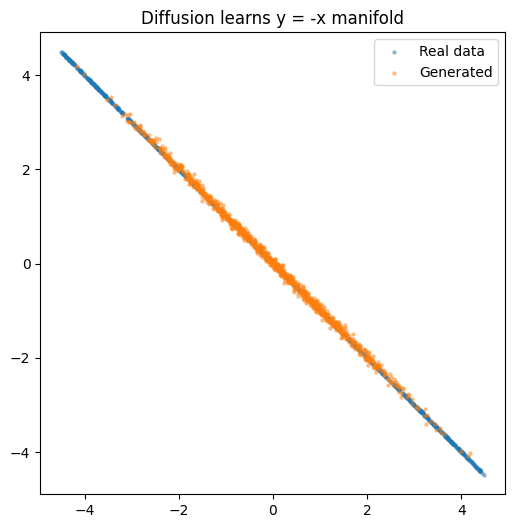

In [36]:
real = sample_line_data(1000)
fake = generate(1000)

plt.figure(figsize=(6,6))
plt.scatter(real[:,0], real[:,1], s=5, alpha=0.4, label="Real data")
plt.scatter(fake[:,0], fake[:,1], s=5, alpha=0.4, label="Generated")
plt.legend()
plt.title("Diffusion learns y = -x manifold")
plt.axis("equal")
plt.show()